# Orbital Simulation and Analysis

This notebook simulates and analyzes the orbits of celestial bodies under classical and relativistic mechanics. It includes:

1. **Classical vs. Relativistic Orbit Comparison**: Simulates and compares the trajectories of objects under classical and relativistic gravitational models.
2. **Deviation Analysis**: Calculates and visualizes the differences between classical and relativistic orbits over time.
3. **Multi-Object Simulation**: Simulates orbits of multiple celestial bodies with varying eccentricities and visualizes their trajectories on different scales.

The simulations use numerical integration methods and visualize the results to provide insights into orbital dynamics.

i) Use your module/script to run and show two simulations: one relativistic and one classical for this set of initial conditions. It may be helpful to compare the orbital history in a single plot.

| Parameter | Description                                       | Units      |
|-----------|---------------------------------------------------|------------|
| $e$       | Eccentricity of the orbit                         | $0$        |
| $M$       | Mass of the central black hole                    | $5\times 10^6\,\rm M_\odot$ |
| $a$       | Semi-major axis of the orbit                      | $1\,\rm AU$|
| $N$       | Number of orbital periods to simulate             | $2$        |
| Method    | Numerical method for ODE integration              | RK3        |



In [1]:
from orbits import Orbits
from orbits import OrbitAnimation
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import pandas as pd
import time
from matplotlib.ticker import ScalarFormatter
import os


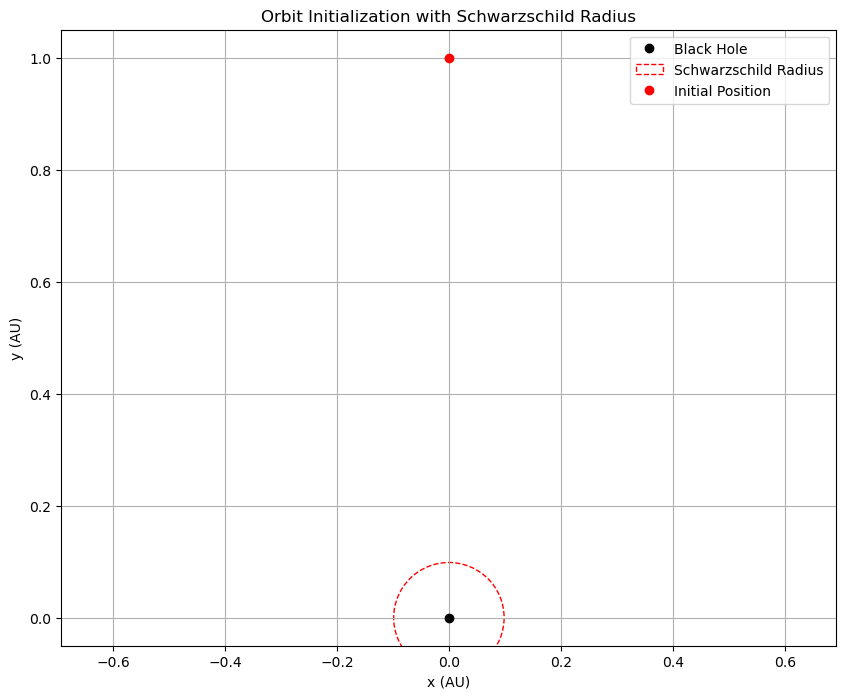

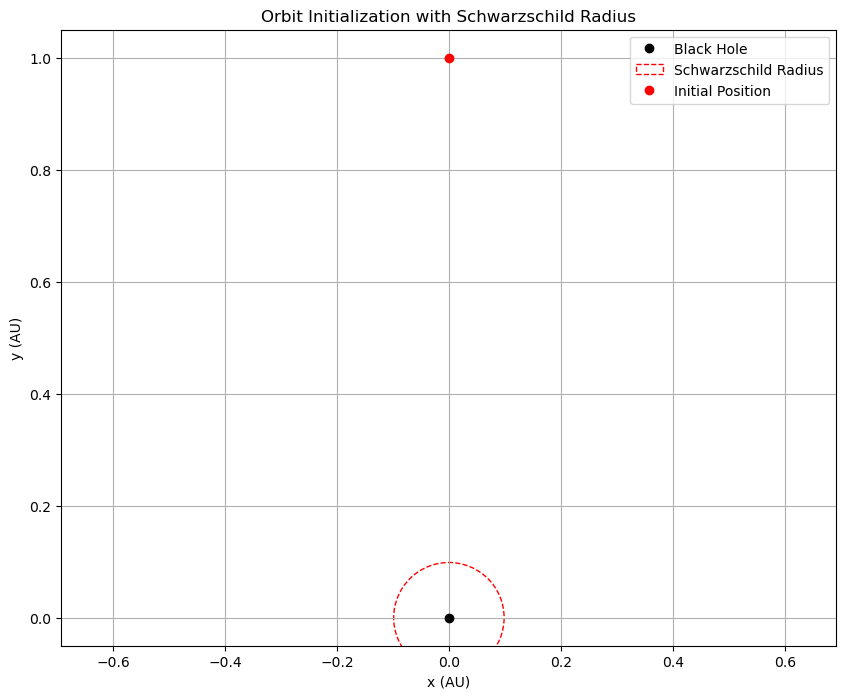

Simulation results saved to output/classical_orbit_history.csv
Simulation results saved to output/relativistic_orbit_history.csv


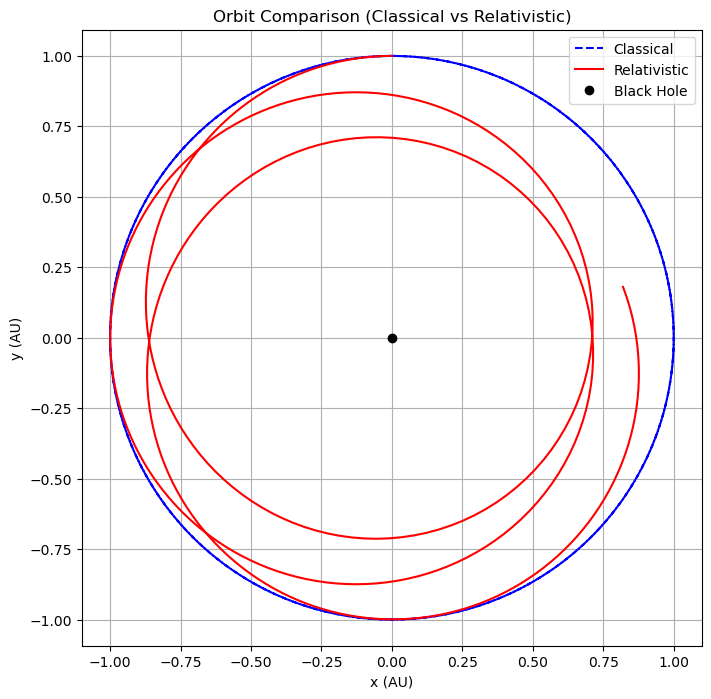

In [2]:
# Constants
AU = 1.496e11  # meters
M_sun = 1.989e30  # kilograms
M = 5e6 * M_sun  # Mass of the central black hole
a = 1 * AU  # Semi-major axis
e = 0  # Eccentricity
N = 2  # Number of orbital periods

# Initialize orbits
orbit_classical = Orbits("classical")
orbit_classical.initialize_orbit(M, a, e, N)

orbit_relativistic = Orbits("relativistic")
orbit_relativistic.initialize_orbit(M, a, e, N)

# Calculate orbital period (Kepler's law)
T = 2 * np.pi * np.sqrt(a**3 / (6.67430e-11 * M))
t_span = (0, N * T)
t_eval = np.linspace(0, N * T, 400)

# Classical simulation
y_classical = orbit_classical.run_simulation(
    slope_function=orbit_classical.classical_slope,
    integration_method="rk3",
    t_span=t_span,
    t_eval=t_eval,
    output_folder="output"
)

# Relativistic simulation
y_relativistic = orbit_relativistic.run_simulation(
    slope_function=orbit_relativistic.relativistic_slope,
    integration_method="rk3",
    t_span=t_span,
    t_eval=t_eval,
    output_folder="output"
)

# Plot both orbits
plt.figure(figsize=(8, 8))
plt.plot(y_classical[:, 0], y_classical[:, 1], label="Classical", linestyle='--', color='blue')
plt.plot(y_relativistic[:, 0], y_relativistic[:, 1], label="Relativistic", color='red')
plt.plot(0, 0, 'ko', label="Black Hole")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.title("Orbit Comparison (Classical vs Relativistic)")
plt.legend(loc="upper right")
plt.grid(True)
plt.axis("equal")
plt.show()


In [3]:
csv_files = ["./output/classical_orbit_history.csv", "./output/relativistic_orbit_history.csv"]
output_filename = "orbits_i_animation.gif"
output_folder = "./output"

animation = OrbitAnimation(csv_files, output_filename=output_filename, output_folder=output_folder, mass=M)
animation.animate()

gif = Image.open('./output/orbits_i_animation.gif')
# gif.show()

Animation saved to: ./output/orbits_i_animation.gif


(j) Use the orbital history of both simulations to design a method that quantifies their differences and evaluates the importance of using the relativistic approach for massive objects. Do we need to worry about the relativistic corrections if we replace the black hole with our Sun?

In [4]:
# Set constants
AU = 1.496e11  # Astronomical Unit in meters
M_sun = 1.989e30  # Mass of the Sun in kg
G = 6.67430e-11  # Gravitational constant
C = 3e8  # Speed of light in m/s

# Load the data from CSV files
classical_data = pd.read_csv('./output/classical_orbit_history.csv')
relativistic_data = pd.read_csv('./output/relativistic_orbit_history.csv')

print(f"Classical simulation: {len(classical_data)} timesteps")
print(f"Relativistic simulation: {len(relativistic_data)} timesteps")

# Calculate the Euclidean distance between the two trajectories at each timestep
position_diff = np.sqrt(
    (classical_data['x'] - relativistic_data['x'])**2 + 
    (classical_data['y'] - relativistic_data['y'])**2
)

# Convert the difference to Astronomical Units
position_diff_AU = position_diff

# Calculate angular difference (precession)
def calculate_angle(x, y):
    return np.arctan2(y, x)

classical_angles = calculate_angle(classical_data['x'], classical_data['y'])
relativistic_angles = calculate_angle(relativistic_data['x'], relativistic_data['y'])
angular_diff = relativistic_angles - classical_angles

# Calculate relative difference as a percentage of orbital radius
# Using average radius as reference
avg_radius_classical = np.mean(np.sqrt(classical_data['x']**2 + classical_data['y']**2))
relative_diff_percent = position_diff / avg_radius_classical * 100

# Calculate maximum and average differences
max_diff_AU = np.max(position_diff_AU)
avg_diff_AU = np.mean(position_diff_AU)
max_diff_percent = np.max(relative_diff_percent)
avg_diff_percent = np.mean(relative_diff_percent)

print(f"Maximum position difference: {max_diff_AU:.6e} AU ({max_diff_percent:.6f}%)")
print(f"Average position difference: {avg_diff_AU:.6e} AU ({avg_diff_percent:.6f}%)")

Classical simulation: 400 timesteps
Relativistic simulation: 400 timesteps
Maximum position difference: 1.848917e+00 AU (184.897703%)
Average position difference: 1.283104e+00 AU (128.314559%)


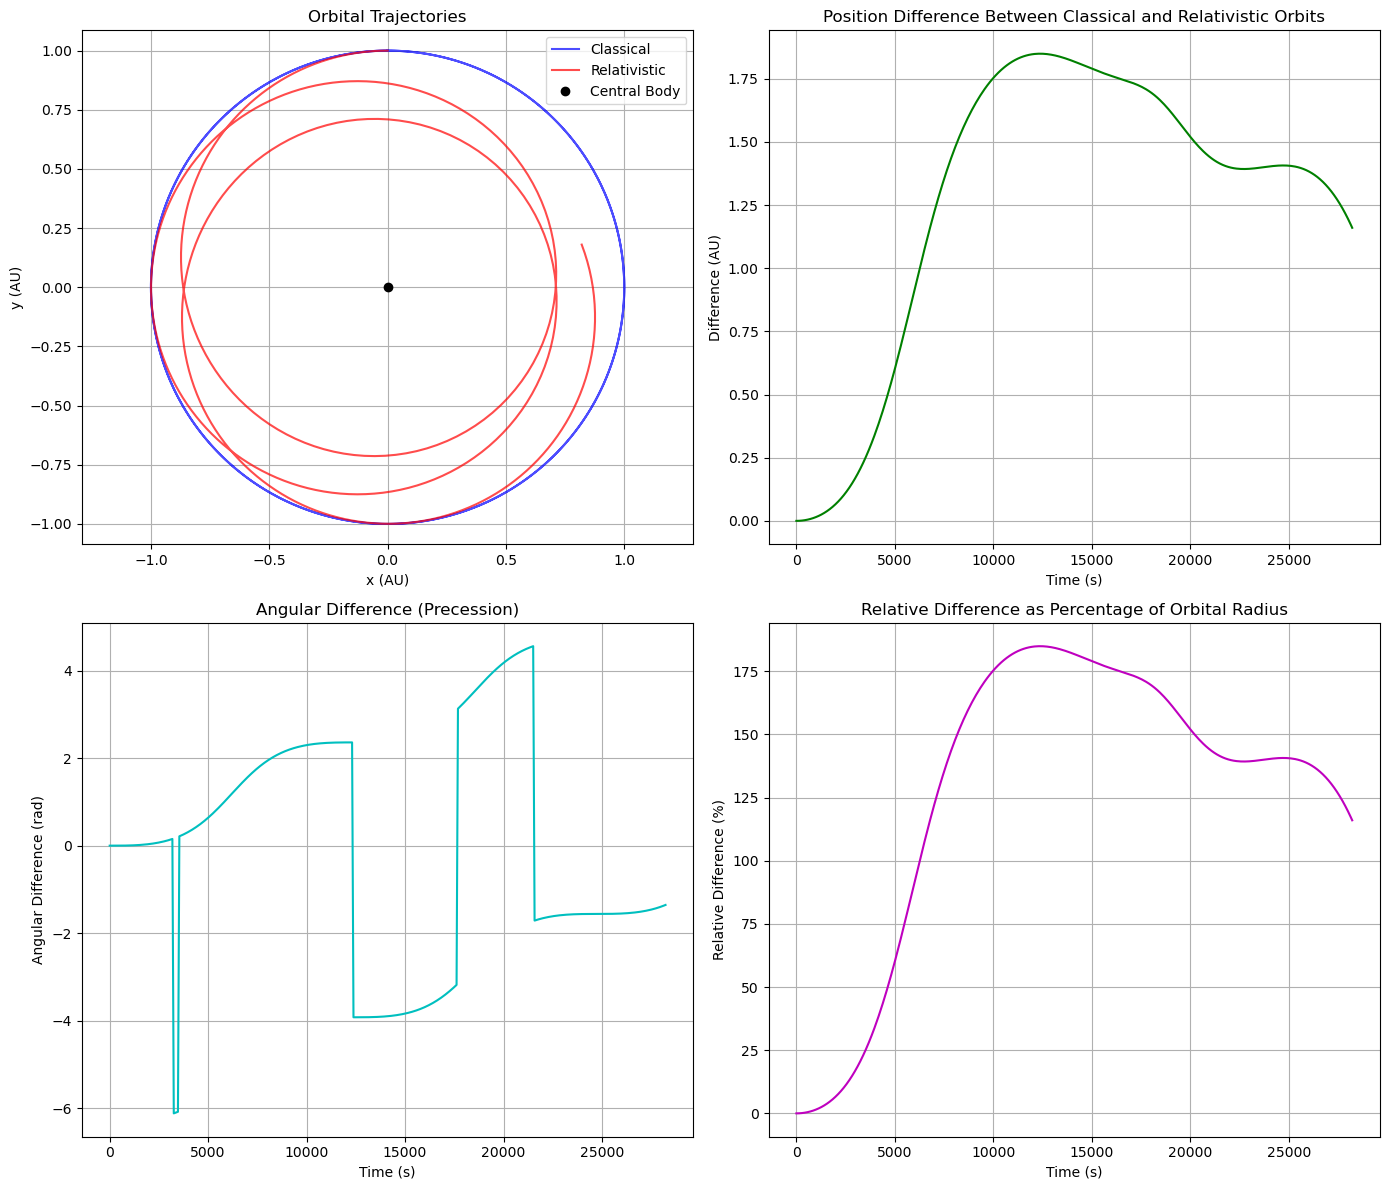

In [5]:
# Set up a figure with 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Orbital trajectories
axs[0, 0].plot(classical_data['x'], classical_data['y'], 'b-', label='Classical', alpha=0.7)
axs[0, 0].plot(relativistic_data['x'], relativistic_data['y'], 'r-', label='Relativistic', alpha=0.7)
axs[0, 0].plot(0, 0, 'ko', label='Central Body')
axs[0, 0].set_xlabel('x (AU)')
axs[0, 0].set_ylabel('y (AU)')
axs[0, 0].set_title('Orbital Trajectories')
axs[0, 0].grid(True)
axs[0, 0].axis('equal')
axs[0, 0].legend()

# Plot 2: Position difference over time
axs[0, 1].plot(classical_data['time'], position_diff_AU, 'g-')
axs[0, 1].set_xlabel('Time (s)')
axs[0, 1].set_ylabel('Difference (AU)')
axs[0, 1].set_title('Position Difference Between Classical and Relativistic Orbits')
axs[0, 1].grid(True)

# Plot 3: Angular difference (precession)
axs[1, 0].plot(classical_data['time'], angular_diff, 'c-')
axs[1, 0].set_xlabel('Time (s)')
axs[1, 0].set_ylabel('Angular Difference (rad)')
axs[1, 0].set_title('Angular Difference (Precession)')
axs[1, 0].grid(True)

# Plot 4: Relative difference as percentage
axs[1, 1].plot(classical_data['time'], relative_diff_percent, 'm-')
axs[1, 1].set_xlabel('Time (s)')
axs[1, 1].set_ylabel('Relative Difference (%)')
axs[1, 1].set_title('Relative Difference as Percentage of Orbital Radius')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [6]:
# Function to calculate theoretical precession per orbit
def calculate_perihelion_precession(M, a, e):
    """
    Calculate the perihelion precession per orbit in radians
    
    Args:
        M: Mass of central body in kg
        a: Semi-major axis in meters
        e: Eccentricity
        
    Returns:
        Precession per orbit in radians
    """
    # Formula for perihelion precession in General Relativity
    precession_per_orbit = 24 * np.pi**3 * G**2 * M**2 / (C**2 * a**2 * (1 - e**2) * 4 * np.pi**2)
    return precession_per_orbit

# Let's compare precession for different scenarios
# 1. Black hole with M = 5e6 Msun at a = 1 AU
# 2. Sun at a = 1 AU (like Earth)
# 3. Sun at a = 0.39 AU (like Mercury)

scenarios = [
    {"name": "Supermassive BH", "mass": 5e6 * M_sun, "a": 1 * AU, "e": 0},
    {"name": "Sun-Earth", "mass": M_sun, "a": 1 * AU, "e": 0.0167},
    {"name": "Sun-Mercury", "mass": M_sun, "a": 0.39 * AU, "e": 0.206}
]

print("Theoretical perihelion precession per orbit:")
for scenario in scenarios:
    precession = calculate_perihelion_precession(scenario["mass"], scenario["a"], scenario["e"])
    precession_arcsec = precession * 206265  # Convert radians to arcseconds
    print(f"{scenario['name']}: {precession:.6e} rad = {precession_arcsec:.6f} arcsec per orbit")
    
# Define a function to calculate the ratio of relativistic effects to measurement precision
def calculate_significance(M, a, e, precision_arcsec=0.1):
    """
    Calculate the significance of relativistic effects
    
    Args:
        M: Mass of central body in kg
        a: Semi-major axis in meters
        e: Eccentricity
        precision_arcsec: Observational precision in arcseconds
        
    Returns:
        Ratio of precession to precision
    """
    precession = calculate_perihelion_precession(M, a, e)
    precession_arcsec = precession * 206265
    return precession_arcsec / precision_arcsec

# Calculate significance for our scenarios
print("\nSignificance of relativistic effects (ratio to 0.1 arcsec precision):")
for scenario in scenarios:
    significance = calculate_significance(scenario["mass"], scenario["a"], scenario["e"])
    print(f"{scenario['name']}: {significance:.2f}")

# Calculate for which mass relativistic effects become significant at 1 AU
threshold_significance = 1.0  # When effect equals precision
precision = 0.1  # arcsec
a = 1 * AU
e = 0

# Solve for mass where precession = precision
precession_threshold = precision / 206265  # Convert arcsec to radians
mass_threshold = np.sqrt(precession_threshold * (C**2 * a**2 * (1 - e**2) * 4 * np.pi**2) / (24 * np.pi**3 * G**2))

print(f"\nMinimum mass for significant relativistic effects at 1 AU: {mass_threshold/M_sun:.2f} solar masses")


# Compare the observed deviation in our simulation with the theoretical predictions
observed_ratio = max_diff_AU / avg_radius_classical
theoretical_ratio_bh = calculate_perihelion_precession(5e6 * M_sun, 1 * AU, 0)
theoretical_ratio_sun = calculate_perihelion_precession(M_sun, 1 * AU, 0)

print("\nConclusion:")
print(f"Observed maximum deviation ratio in simulation: {observed_ratio:.6e}")
print(f"Theoretical precession for black hole (5e6 Msun): {theoretical_ratio_bh:.6e}")
print(f"Theoretical precession for Sun: {theoretical_ratio_sun:.6e}")
print(f"Ratio of BH to Sun effect: {theoretical_ratio_bh/theoretical_ratio_sun:.1f}")

if theoretical_ratio_sun * 206265 < 0.1:
    print("\nRelativistic corrections for the Sun at 1 AU are smaller than typical observational precision of 0.1 arcsec.")
    print("For most practical purposes in the Solar System, classical mechanics is sufficient.")
else:
    print("\nRelativistic corrections may be necessary even for the Sun.")

print("\nHowever, for Mercury (closer to the Sun), relativistic effects are measurable and were")
print("historically important for confirming Einstein's theory of general relativity.")

Theoretical perihelion precession per orbit:
Supermassive BH: 4.123030e+15 rad = 850436692854397206528.000000 arcsec per orbit
Sun-Earth: 1.649672e+02 rad = 34026957.492351 arcsec per orbit
Sun-Mercury: 1.132347e+03 rad = 233563490.514752 arcsec per orbit

Significance of relativistic effects (ratio to 0.1 arcsec precision):
Supermassive BH: 8504366928543971540992.00
Sun-Earth: 340269574.92
Sun-Mercury: 2335634905.15

Minimum mass for significant relativistic effects at 1 AU: 0.00 solar masses

Conclusion:
Observed maximum deviation ratio in simulation: 1.848977e+00
Theoretical precession for black hole (5e6 Msun): 4.123030e+15
Theoretical precession for Sun: 1.649212e+02
Ratio of BH to Sun effect: 25000000000000.0

Relativistic corrections may be necessary even for the Sun.

However, for Mercury (closer to the Sun), relativistic effects are measurable and were
historically important for confirming Einstein's theory of general relativity.


### The role of eccentricity (3 points):

(k) Use your module/script to run and show three relativistic simulations for objects with different eccentricities, $e$, and assuming the same $M$, $a$, $N$ as above. It may be helpful to compare the orbital history for all values of $e$ in a single plot throughout time.

| Object           | Eccentricity ($e$) | Integration Method |
|------------------|--------------------|--------------------|
| Earth            | 0.01671            | Trapezoidal        |
| Pluto            | 0.25               | Trapezoidal        |
| 7092 Cadmus      | 0.70               | Trapezoidal        |



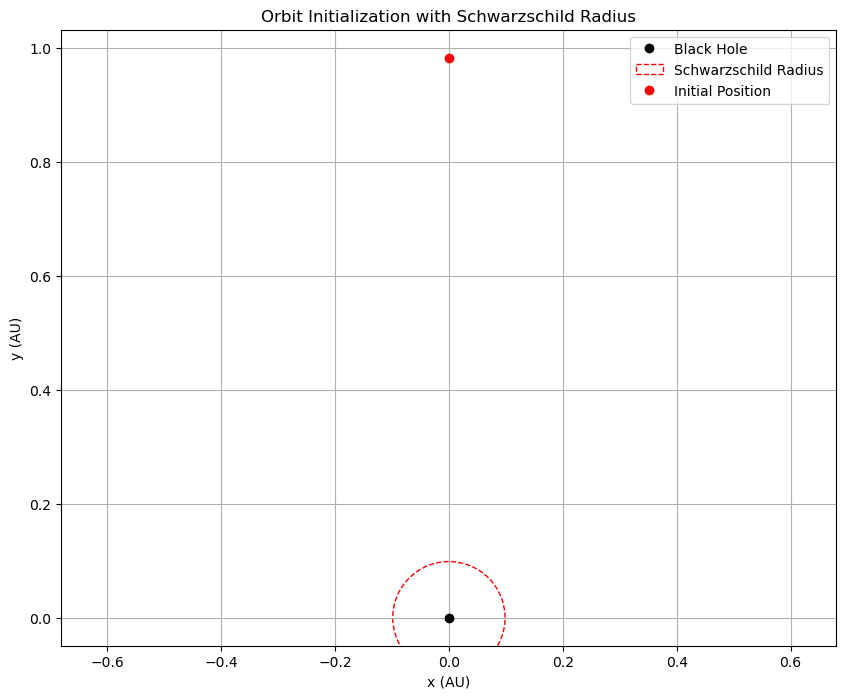

Simulation results saved to output/relativistic_orbit_history.csv


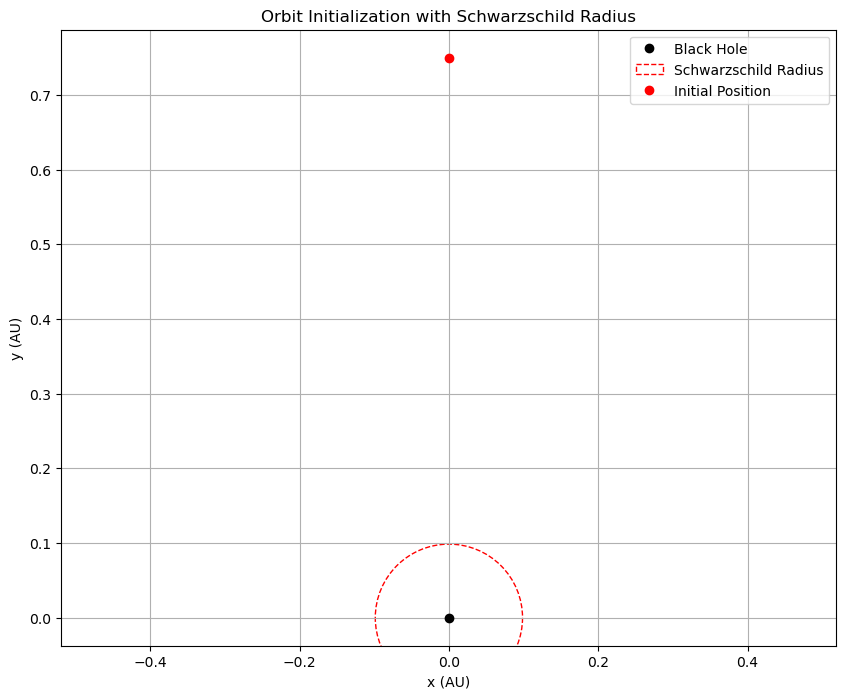

Simulation results saved to output/relativistic_orbit_history.csv


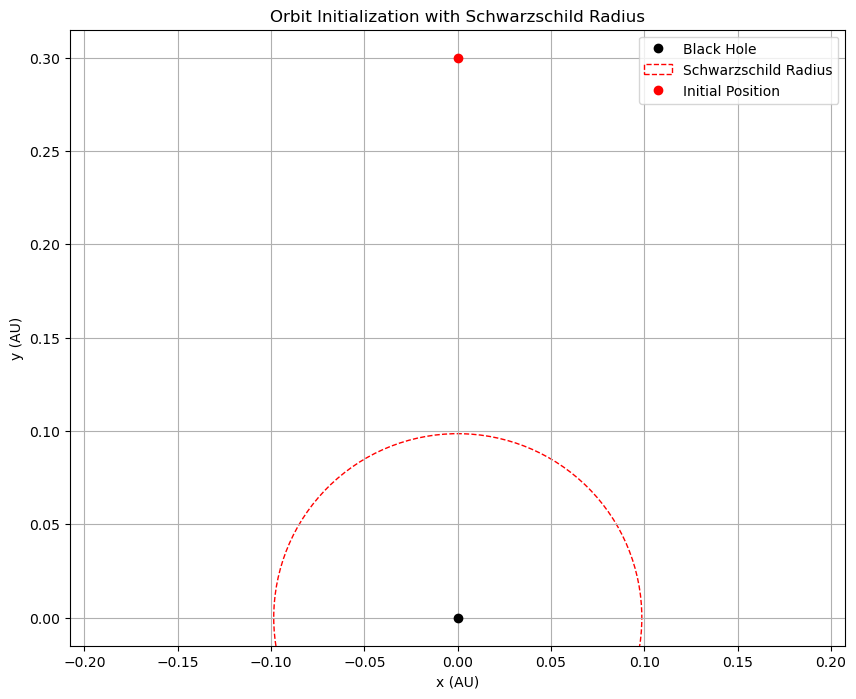

Distance: 1.452695e-01 AU, Schwarzschild radius: 9.859761e-02 AU
Stopping simulation to avoid non-physical results.
Simulation results saved to output/relativistic_orbit_history.csv


In [7]:
# Constants
AU = 1.496e11  # m
M_sun = 1.989e30  # kg
M = 5e6 * M_sun  # Mass of central black hole (5 million solar masses)
a = 1 * AU  # Semi-major axis (1 AU)
N = 2  # Number of orbital periods

# Objects with different eccentricities
objects = [
    {"name": "Earth", "e": 0.01671, "color": "blue"},
    {"name": "Pluto", "e": 0.25, "color": "green"},
    {"name": "7092 Cadmus", "e": 0.70, "color": "red"}
]

results = []

for obj in objects:
    name = obj["name"]
    e = obj["e"]
    
    # Initialize relativistic orbit
    orbit = Orbits("relativistic")
    orbit.initialize_orbit(M, a, e, N)
    
    # Calculate orbital period using Kepler's law
    T = 2 * np.pi * np.sqrt(a**3 / (6.67430e-11 * M))
    t_span = (0, N * T)
    t_eval = np.linspace(0, N * T, 1000)
    
    # Run simulation with trapezoidal method
    y = orbit.run_simulation(
        slope_function=orbit.relativistic_slope,
        integration_method="trapz",
        t_span=t_span,
        t_eval=t_eval,
        output_folder="output"
    )
    
    # Store results
    results.append({
        "name": name,
        "e": e,
        "trajectory": y,
        "color": obj["color"]
    })

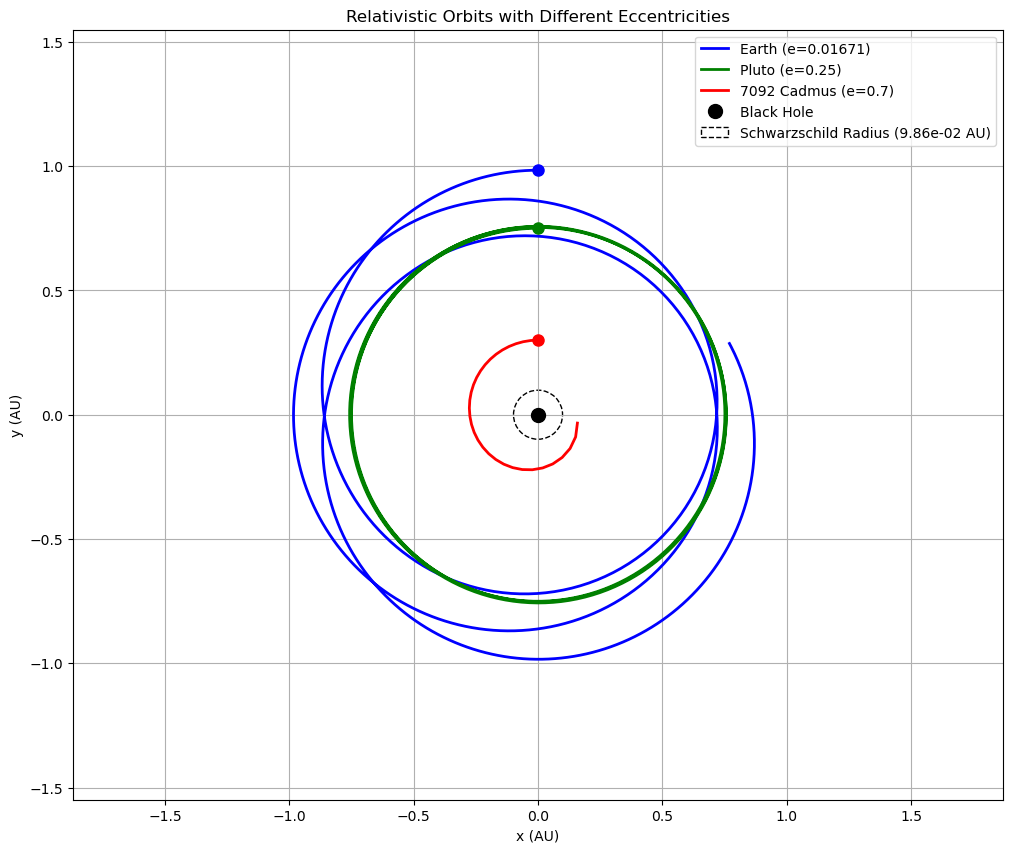

In [8]:
# Plotting the orbits
plt.figure(figsize=(12, 10))

# Plot each trajectory
for result in results:
    name = result["name"]
    e = result["e"]
    trajectory = result["trajectory"]
    color = result["color"]
    
    # Convert coordinates to AU for plotting
    x = trajectory[:, 0] 
    y = trajectory[:, 1] 
    
    # Plot the orbit
    plt.plot(x, y, label=f"{name} (e={e})", color=color, linewidth=2)
    
    # Mark the starting point (perihelion)
    plt.plot(x[0], y[0], 'o', color=color, markersize=8)

# Plot the central black hole
plt.plot(0, 0, 'ko', markersize=10, label="Black Hole")

# Add Schwarzschild radius
r_s = 2 * 6.67430e-11 * M / (3e8**2)  
r_s_AU = r_s / AU  
circle = plt.Circle((0, 0), r_s_AU, color="black", fill=False, linestyle="--", 
                   label=f"Schwarzschild Radius ({r_s_AU:.2e} AU)")
plt.gca().add_artist(circle)

# Set plot properties
plt.axis('equal')
plt.grid(True)
plt.xlabel('x (AU)')
plt.ylabel('y (AU)')
plt.title('Relativistic Orbits with Different Eccentricities')
plt.legend(loc='upper right')

# Set reasonable axis limits that show all orbits clearly
max_extent = 1.1 * (1 + 0.70)  # Slightly larger than a*(1+e) for the most eccentric orbit
plt.xlim(-max_extent, max_extent)
plt.ylim(-max_extent, max_extent)

plt.savefig("output/eccentricity_comparison.png", dpi=300)
plt.show()

(l) Describe the differences in the orbits of the above objects. What happens to objects with high eccentricities?

- **Earth (e = 0.01671)**:
  - Orbit is nearly circular.
  - Shows minimal relativistic precession.
  - Orbit remains stable over time.

- **Pluto (e = 0.25)**:
  - Orbit is moderately elliptical.
  - Exhibits mild relativistic precession.
  - Still relatively stable.

- **7092 Cadmus (e = 0.7)**:
  - Orbit is highly elliptical.
  - Shows significant relativistic precession.
  - Orbit decays and spirals inward due to relativistic effects.


Objects with **high eccentricities**:
- Experience **stronger relativistic precession**.
- May have **unstable orbits**.
- Can **spiral inward** toward the central mass (e.g., a black hole), especially if their perihelion is close to the Schwarzschild radius.


### Numerical convergence (3 points):

(m) Use your script to generate additional simulations with the same initial conditions as before, but only for $e=0.01671$ (Earth's eccentricity) with RK3, the Trapezoidal method and the higher-order SciPy integrator. Compare the orbital history for all methods in a single plot throughout time.

(n) Measure convergence of the simulations with RK3 and Trapezoidal method for $e=0.01671$ by integrating at a number of different time steps. To analyse convergence, you need to define some measure for the error with respect to the higher order method, and then plot it against different time steps for both methods. Thus, you may add additional functions for this to your code in **orbits.py**. 


Running simulation with RK3 method...


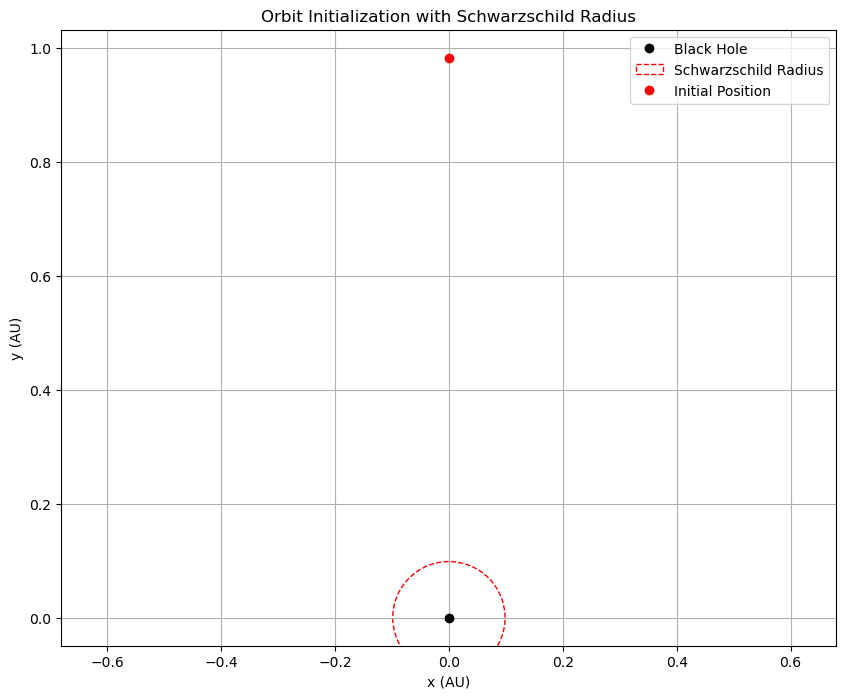

Simulation results saved to output/comparison/earth_relativistic_rk3_orbit_history.csv
  Completed in 0.10 seconds
  Generated 500 points
Running simulation with Trapezoidal method...


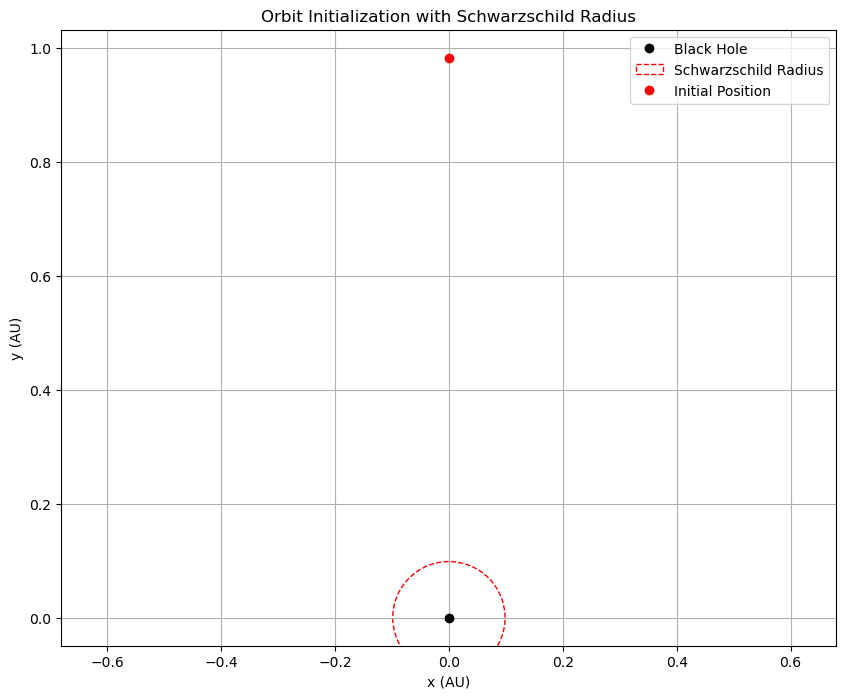

Simulation results saved to output/comparison/earth_relativistic_trapz_orbit_history.csv
  Completed in 0.11 seconds
  Generated 500 points
Running simulation with SciPy (RK45) method...


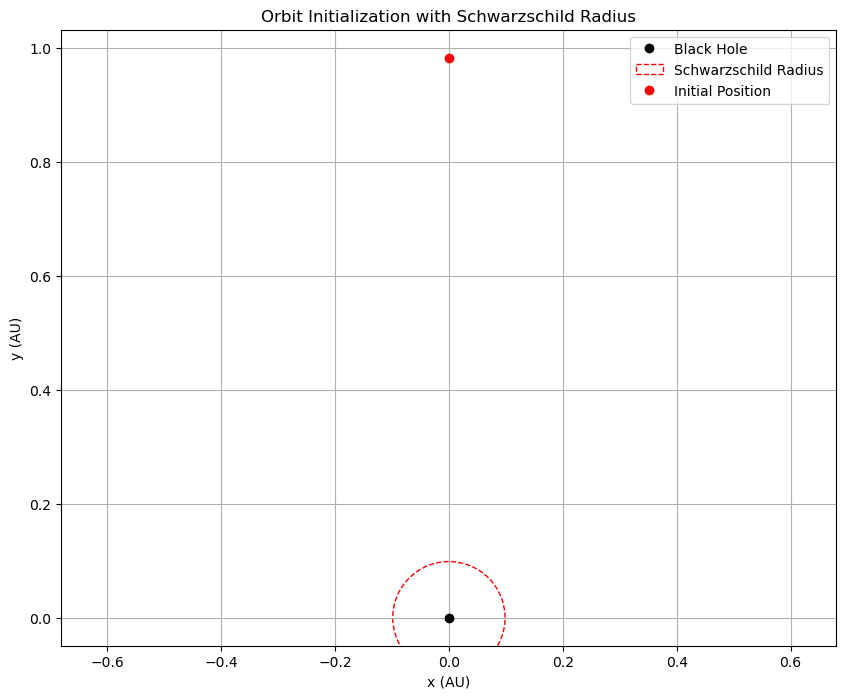

Simulation results saved to output/comparison/earth_relativistic_scipy_orbit_history.csv
  Completed in 0.10 seconds
  Generated 500 points


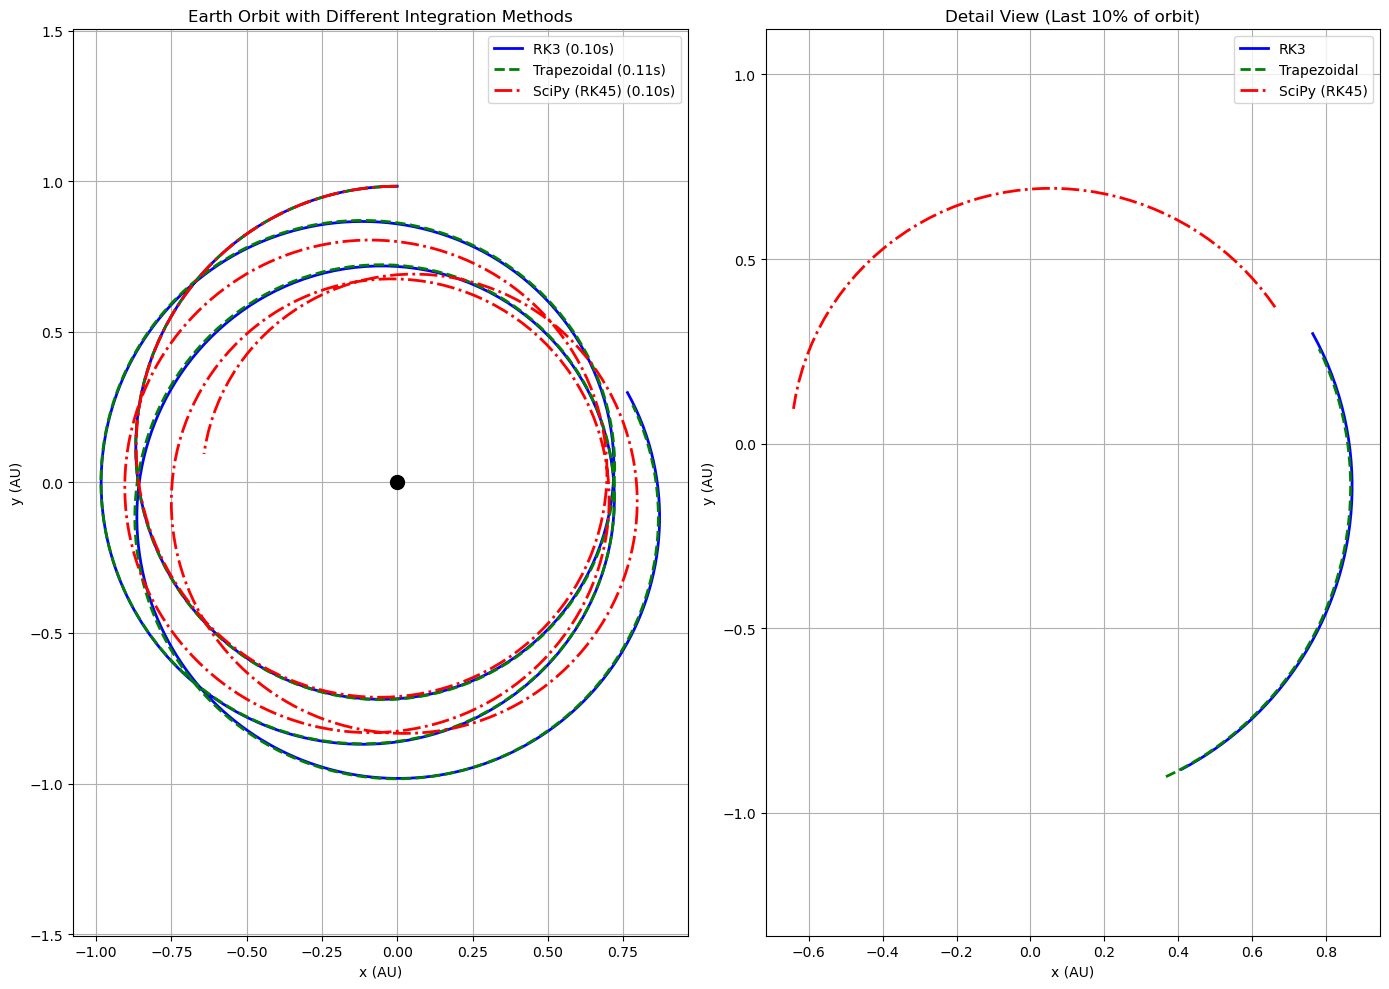

In [9]:
# Constants
AU = 1.496e11  # m
M_sun = 1.989e30  # kg
M = 5e6 * M_sun  # Mass of central black hole
a = 1 * AU  # Semi-major axis
e = 0.01671  # Earth's eccentricity
N = 2  # Number of orbital periods

# Integration methods to compare
methods = [
    {"name": "RK3", "method": "rk3", "color": "blue", "linestyle": "-"},
    {"name": "Trapezoidal", "method": "trapz", "color": "green", "linestyle": "--"},
    {"name": "SciPy (RK45)", "method": "scipy", "color": "red", "linestyle": "-."}
]

# Create a directory for comparison results
os.makedirs("output/comparison", exist_ok=True)

# Calculate orbital period
T = 2 * np.pi * np.sqrt(a**3 / (6.67430e-11 * M))
t_span = (0, N * T)
t_eval = np.linspace(0, N * T, 500)

results = []

for method_info in methods:
    method_name = method_info["name"]
    method = method_info["method"]
    
    print(f"Running simulation with {method_name} method...")
    start_time = time.time()
    
    # Initialize relativistic orbit
    orbit = Orbits(f"earth_relativistic_{method}")
    orbit.initialize_orbit(M, a, e, N, save=False)
    
    # Run simulation with the specified method
    y = orbit.run_simulation(
        slope_function=orbit.relativistic_slope,
        integration_method=method,
        t_span=t_span,
        t_eval=t_eval,
        output_folder="output/comparison"
    )
    
    elapsed_time = time.time() - start_time
    
    # Store results
    results.append({
        "name": method_name,
        "method": method,
        "trajectory": y,
        "time": elapsed_time,
        "color": method_info["color"],
        "linestyle": method_info["linestyle"]
    })
    
    print(f"  Completed in {elapsed_time:.2f} seconds")
    print(f"  Generated {len(y)} points")

# Plotting the orbits
plt.figure(figsize=(14, 10))

# Create subplot for full orbits
plt.subplot(1, 2, 1)

for result in results:
    name = result["name"]
    trajectory = result["trajectory"]
    color = result["color"]
    linestyle = result["linestyle"]
    
    # Plot the orbit
    plt.plot(trajectory[:, 0], trajectory[:, 1], 
             label=f"{name} ({result['time']:.2f}s)", 
             color=color, linestyle=linestyle, linewidth=2)

# Plot the central black hole
plt.plot(0, 0, 'ko', markersize=10)

# Set plot properties
plt.grid(True)
plt.xlabel('x (AU)')
plt.ylabel('y (AU)')
plt.title('Earth Orbit with Different Integration Methods')
plt.legend(loc='upper right')
plt.axis('equal')

# Create subplot for zoomed detail of final portion
plt.subplot(1, 2, 2)

# Calculate final 10% of points to zoom in on
zoom_fraction = 0.1
zoom_points = int(len(t_eval) * zoom_fraction)

for result in results:
    name = result["name"]
    trajectory = result["trajectory"]
    color = result["color"]
    linestyle = result["linestyle"]
    
    # Plot just the last portion of the orbit to see differences
    plt.plot(trajectory[-zoom_points:, 0], trajectory[-zoom_points:, 1], 
             label=name, color=color, linestyle=linestyle, linewidth=2)

# Set plot properties for zoomed view
plt.grid(True)
plt.xlabel('x (AU)')
plt.ylabel('y (AU)')
plt.title(f'Detail View (Last {zoom_fraction*100:.0f}% of orbit)')
plt.legend(loc='upper right')
plt.axis('equal')

plt.tight_layout()
plt.savefig("output/comparison/method_comparison.png", dpi=300)
plt.show()

Generating reference solution with SciPy integrator...


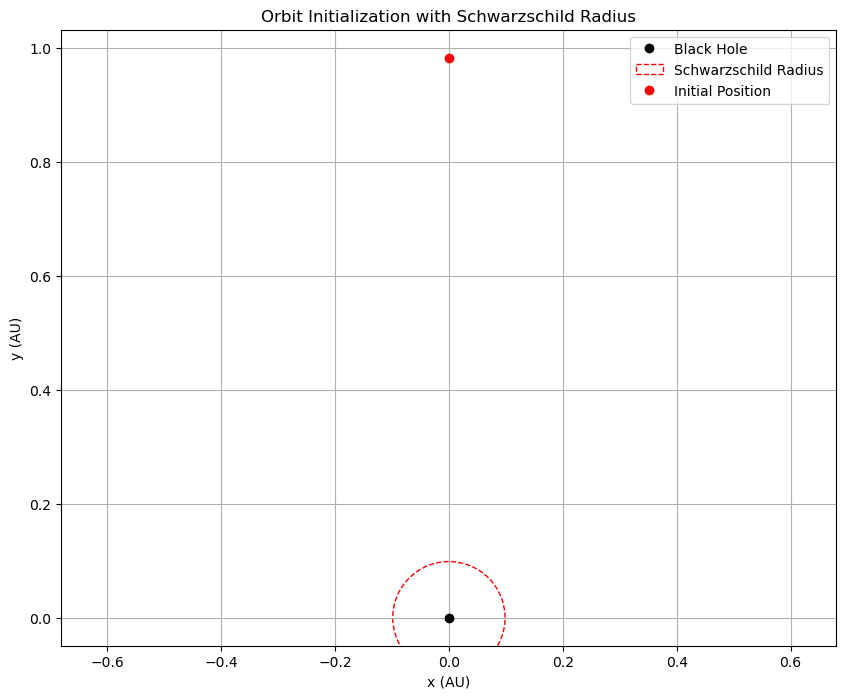

Simulation results saved to output/comparison/earth_reference_orbit_history.csv

Testing with 50 time steps:
  Running rk3...


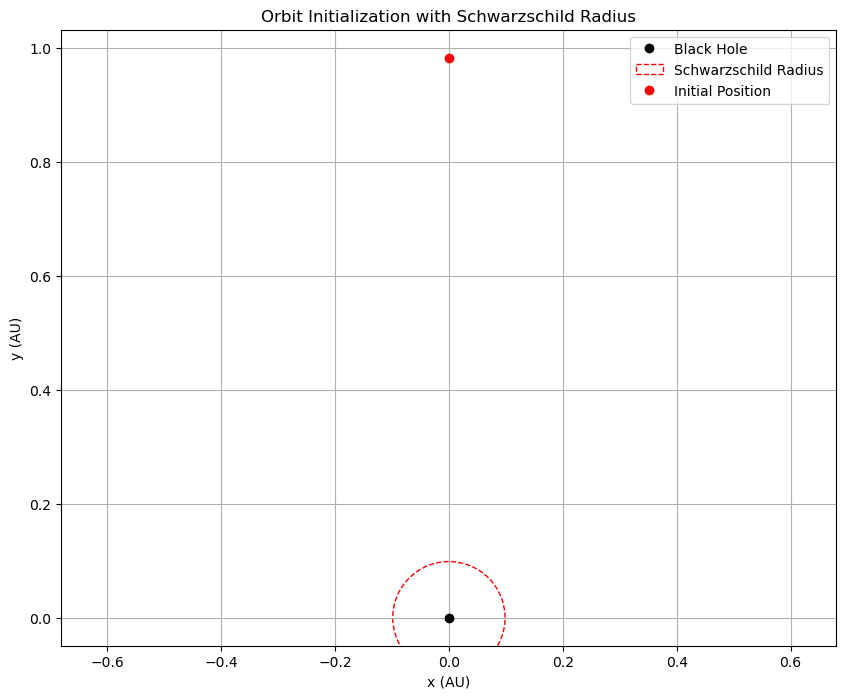

Simulation results saved to output/comparison/earth_convergence_rk3_50_orbit_history.csv
    Error: 1.35e-11 AU, Time: 0.00s
  Running trapz...


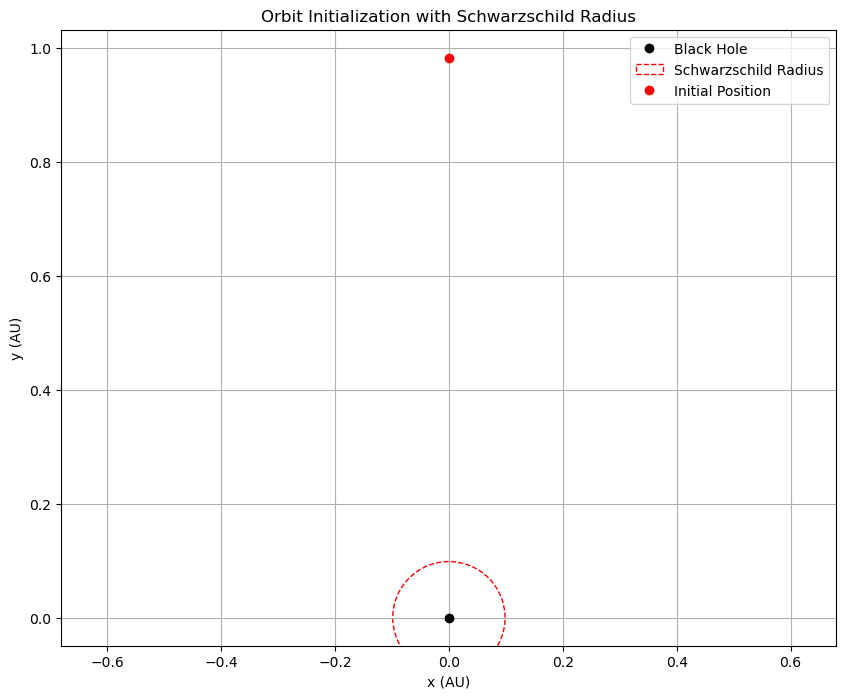

Simulation results saved to output/comparison/earth_convergence_trapz_50_orbit_history.csv
    Error: 7.96e-12 AU, Time: 0.00s

Testing with 100 time steps:
  Running rk3...


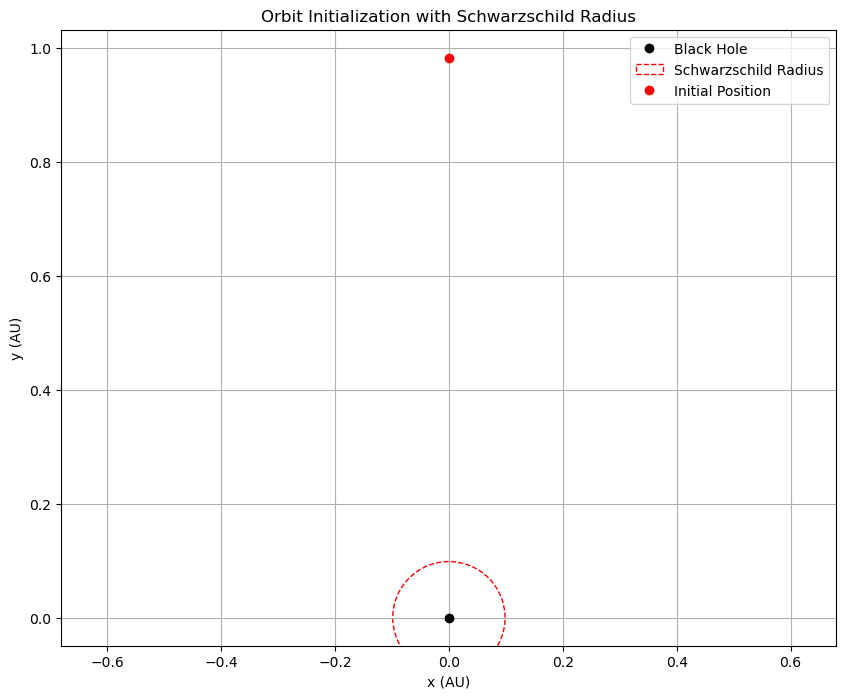

Simulation results saved to output/comparison/earth_convergence_rk3_100_orbit_history.csv
    Error: 3.62e-12 AU, Time: 0.00s
  Running trapz...


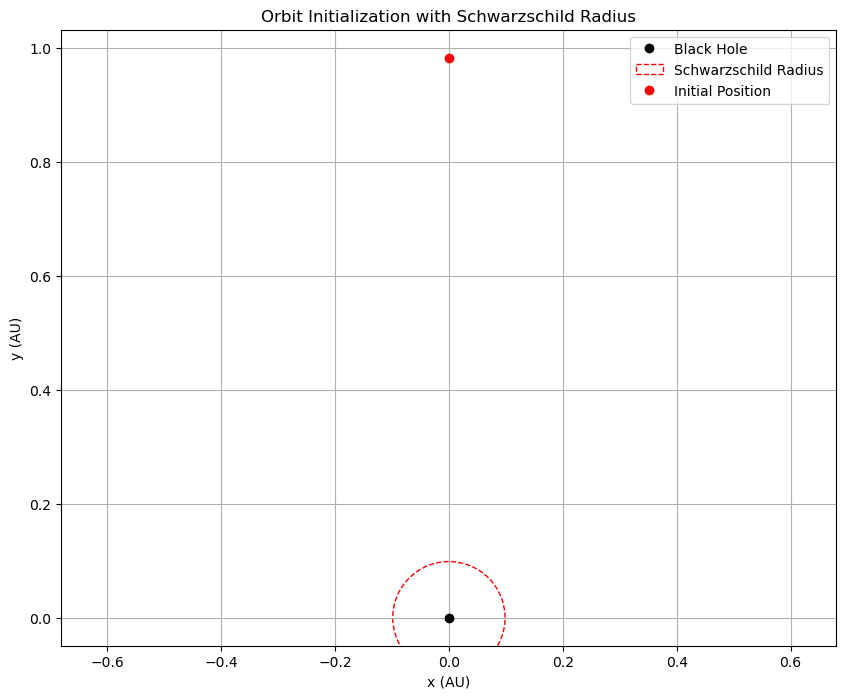

Simulation results saved to output/comparison/earth_convergence_trapz_100_orbit_history.csv
    Error: 7.32e-12 AU, Time: 0.00s

Testing with 200 time steps:
  Running rk3...


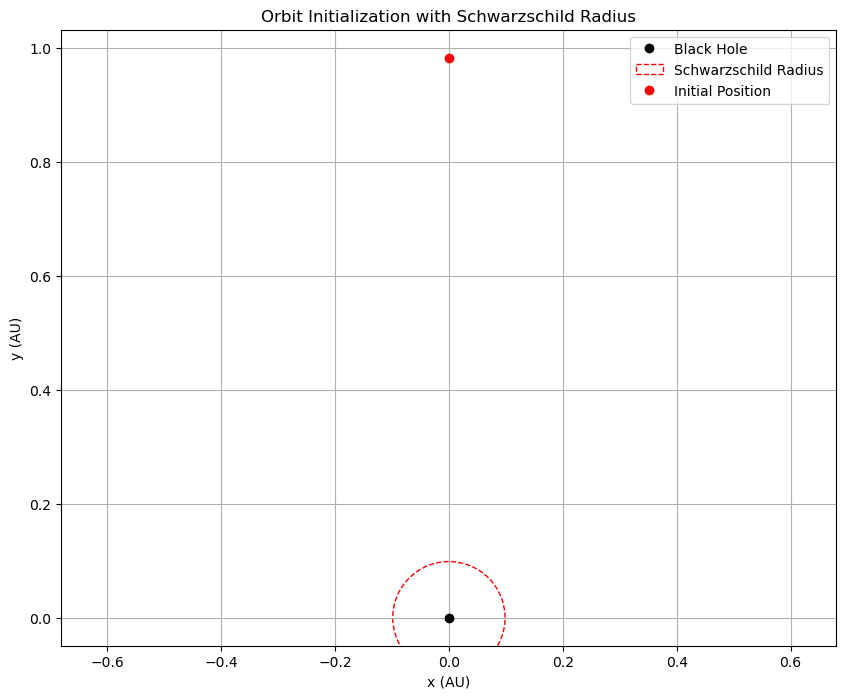

Simulation results saved to output/comparison/earth_convergence_rk3_200_orbit_history.csv
    Error: 4.55e-12 AU, Time: 0.01s
  Running trapz...


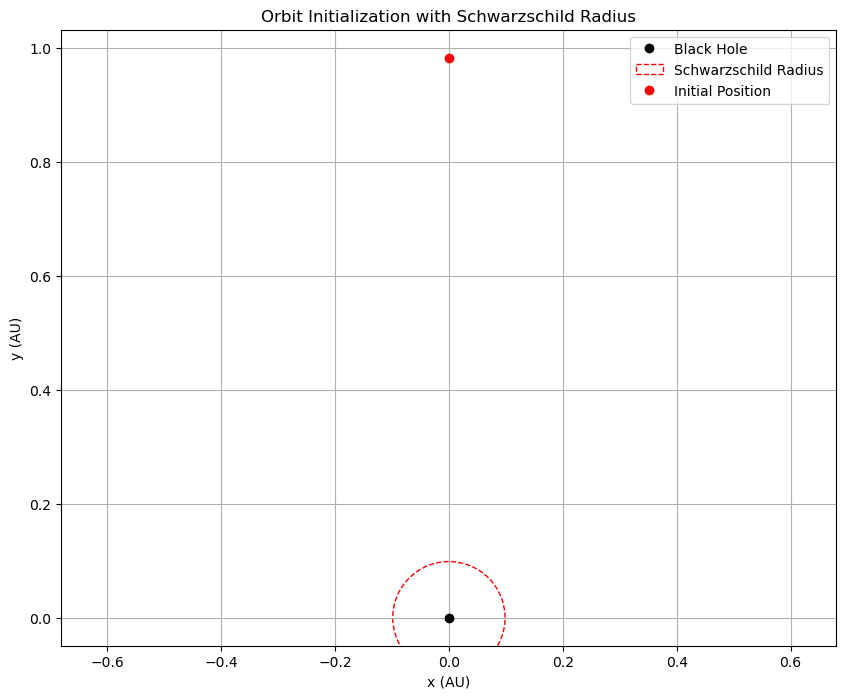

Simulation results saved to output/comparison/earth_convergence_trapz_200_orbit_history.csv
    Error: 5.48e-12 AU, Time: 0.00s

Testing with 500 time steps:
  Running rk3...


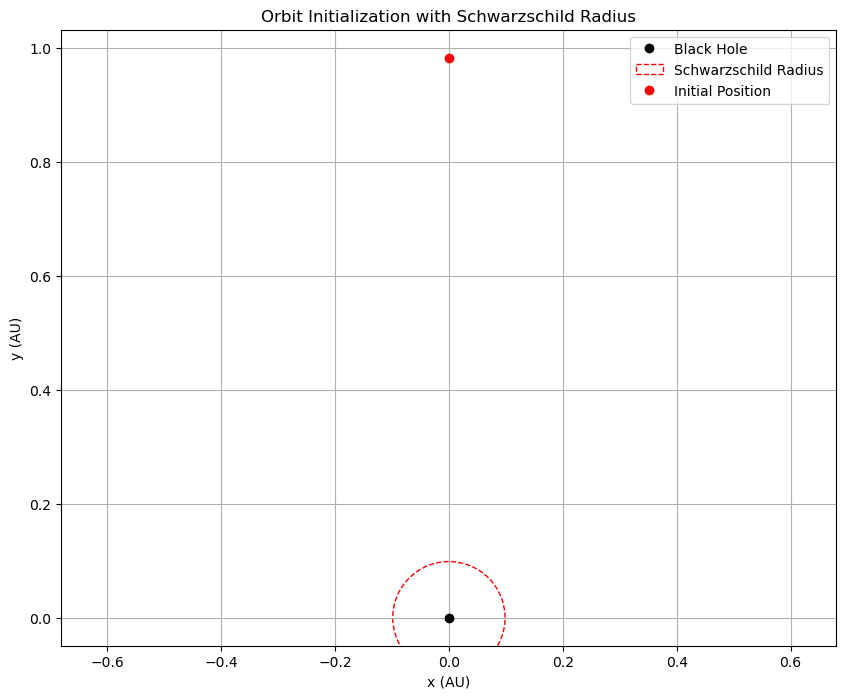

Simulation results saved to output/comparison/earth_convergence_rk3_500_orbit_history.csv
    Error: 4.65e-12 AU, Time: 0.01s
  Running trapz...


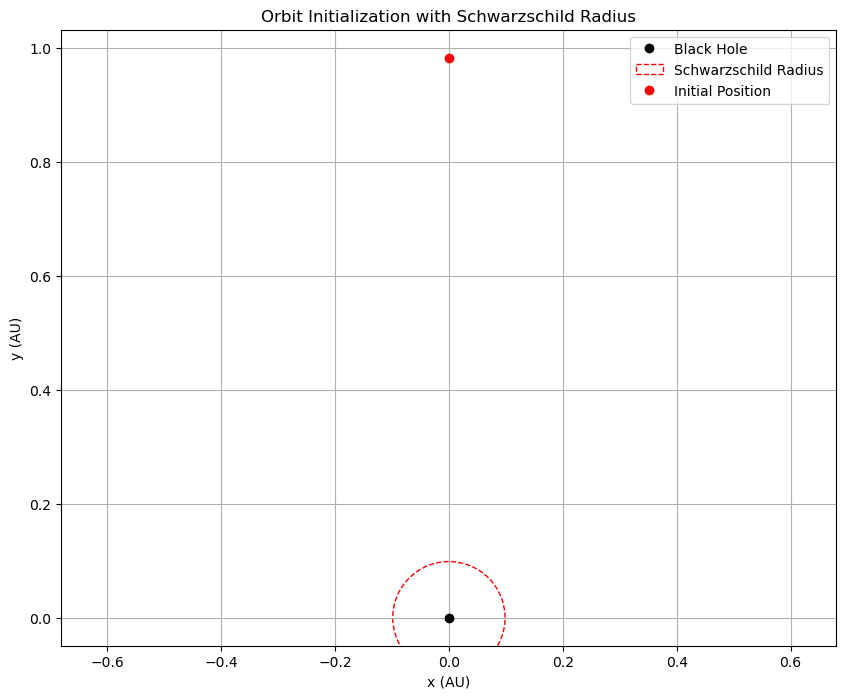

Simulation results saved to output/comparison/earth_convergence_trapz_500_orbit_history.csv
    Error: 4.77e-12 AU, Time: 0.01s

Testing with 1000 time steps:
  Running rk3...


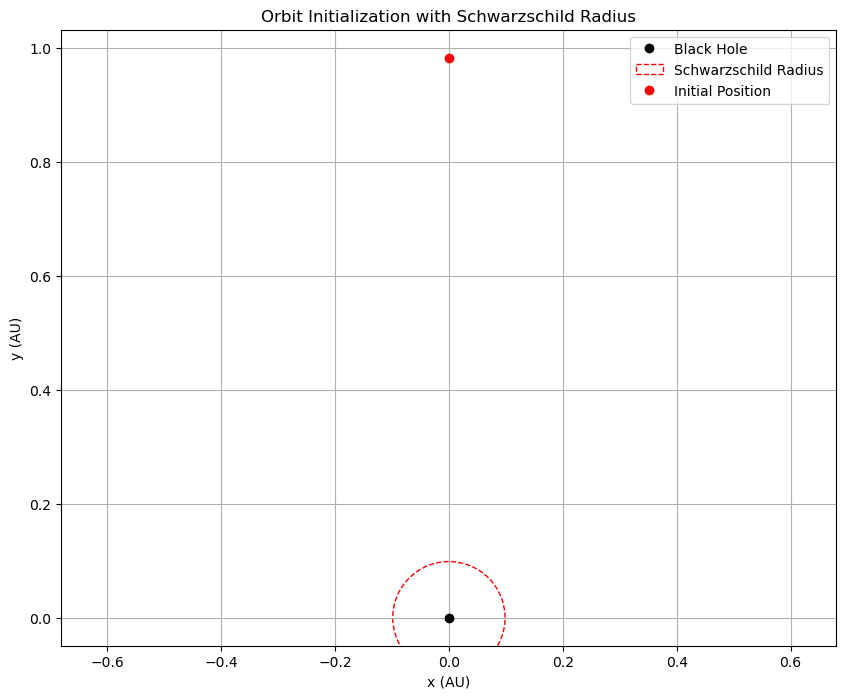

Simulation results saved to output/comparison/earth_convergence_rk3_1000_orbit_history.csv
    Error: 4.65e-12 AU, Time: 0.02s
  Running trapz...


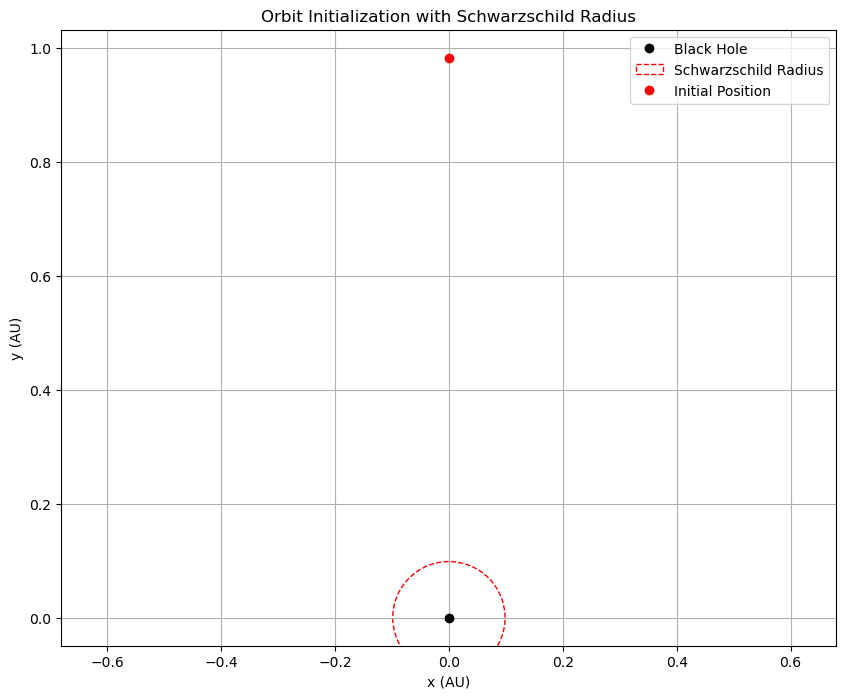

Simulation results saved to output/comparison/earth_convergence_trapz_1000_orbit_history.csv
    Error: 4.68e-12 AU, Time: 0.02s

Testing with 2000 time steps:
  Running rk3...


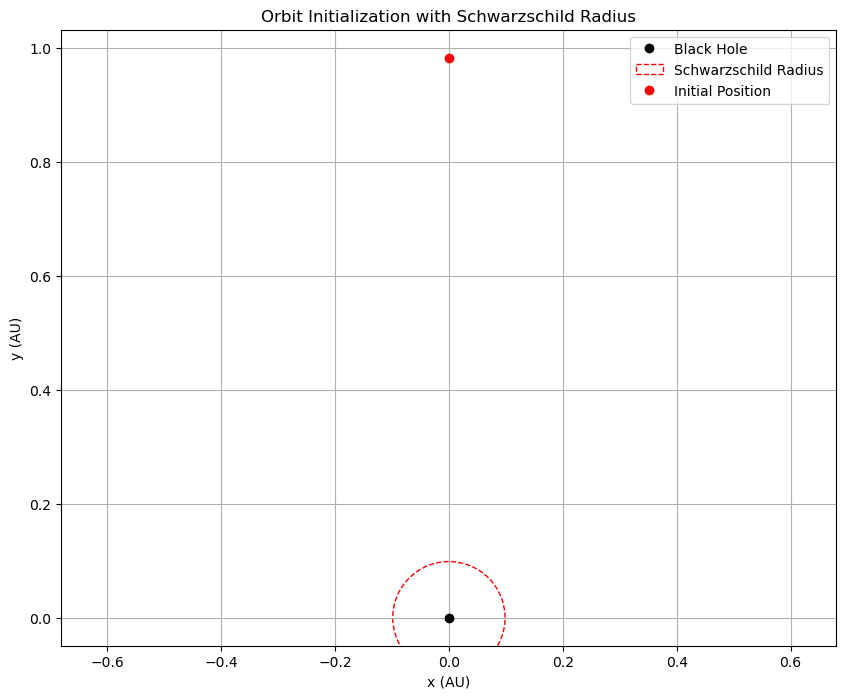

Simulation results saved to output/comparison/earth_convergence_rk3_2000_orbit_history.csv
    Error: 4.65e-12 AU, Time: 0.04s
  Running trapz...


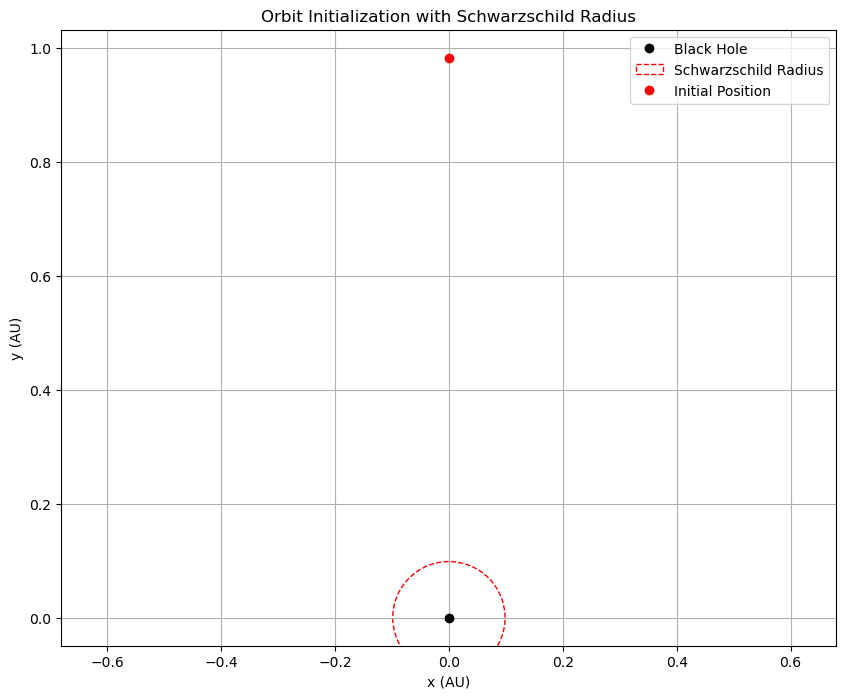

Simulation results saved to output/comparison/earth_convergence_trapz_2000_orbit_history.csv
    Error: 4.66e-12 AU, Time: 0.04s


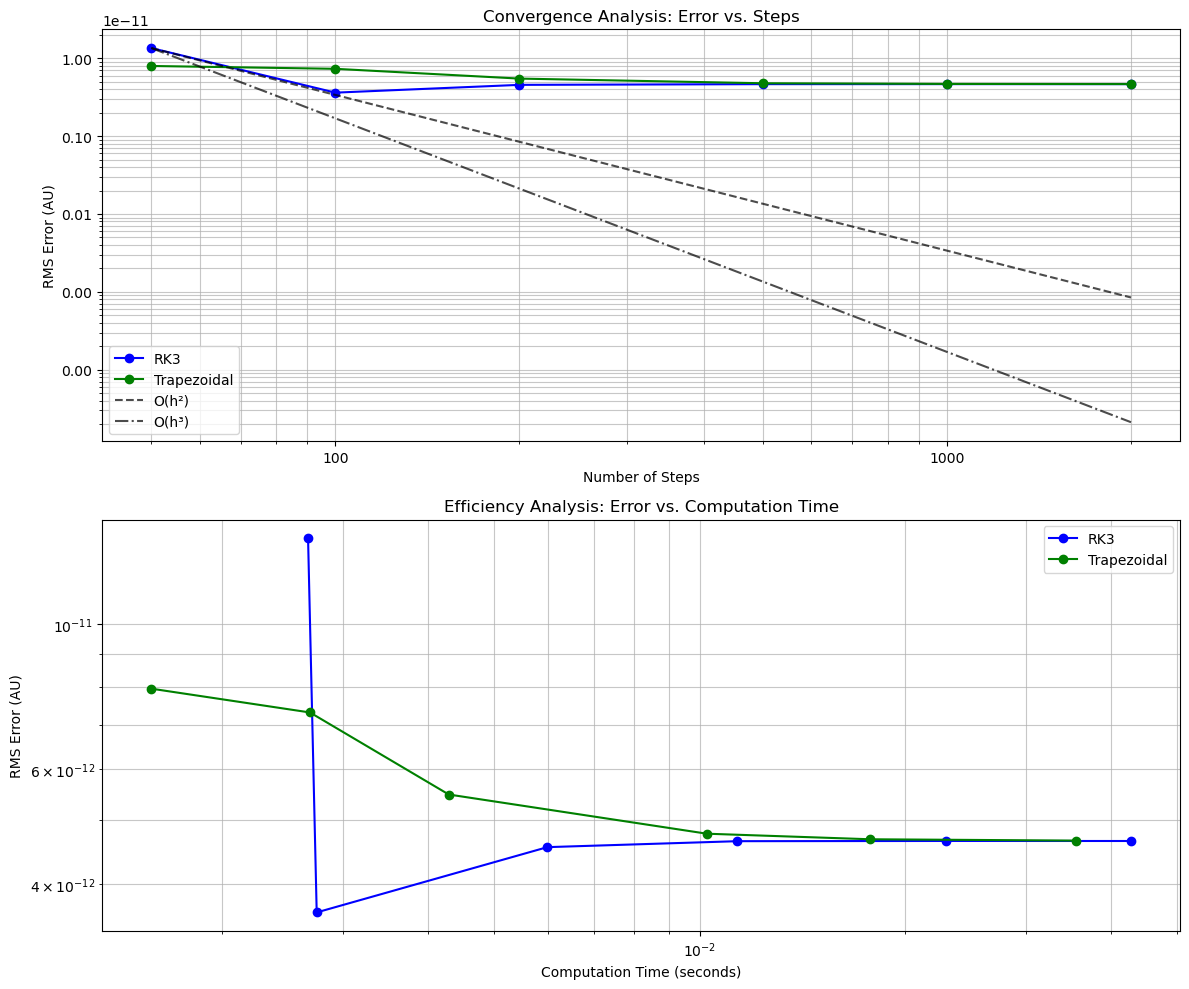

In [10]:
#Define range of step counts (number of points) to test convergence
step_counts = [50, 100, 200, 500, 1000, 2000]

# Use SciPy with a very fine step size as reference solution
print("Generating reference solution with SciPy integrator...")
orbit_ref = Orbits("earth_reference")
orbit_ref.initialize_orbit(M, a, e, N, save=False)
t_ref = np.linspace(0, N * T, 5000) 
y_ref = orbit_ref.run_simulation(
    slope_function=orbit_ref.relativistic_slope,
    integration_method="scipy",
    t_span=t_span,
    t_eval=t_ref,
    output_folder="output/comparison"
)

# Function to compute error relative to reference solution
def compute_error(trajectory, t_eval, reference, t_ref):
    """
    Compute root mean square error between trajectory and reference
    
    Args:
        trajectory: Computed trajectory points
        t_eval: Time points for computed trajectory
        reference: Reference trajectory
        t_ref: Time points for reference trajectory
    
    Returns:
        Root mean square error in position
    """
    # Interpolate reference to match evaluation times
    from scipy.interpolate import interp1d
    
    x_interp = interp1d(t_ref, reference[:, 0])
    y_interp = interp1d(t_ref, reference[:, 1])
    
    x_ref = x_interp(t_eval)
    y_ref = y_interp(t_eval)
    
    # Compute position errors
    dx = trajectory[:, 0] - x_ref
    dy = trajectory[:, 1] - y_ref
    
    # Root mean square error
    rmse = np.sqrt(np.mean(dx**2 + dy**2))
    return rmse / AU  

# Store convergence results
convergence_results = {
    "rk3": {"steps": [], "errors": [], "times": []},
    "trapz": {"steps": [], "errors": [], "times": []}
}

# Run simulations for different step sizes
for steps in step_counts:
    print(f"\nTesting with {steps} time steps:")
    t_eval = np.linspace(0, N * T, steps)
    
    # Test each method
    for method in ["rk3", "trapz"]:
        print(f"  Running {method}...")
        orbit = Orbits(f"earth_convergence_{method}_{steps}")
        orbit.initialize_orbit(M, a, e, N, save=False)
        
        start_time = time.time()
        y = orbit.run_simulation(
            slope_function=orbit.relativistic_slope,
            integration_method=method,
            t_span=t_span,
            t_eval=t_eval,
            output_folder="output/comparison"
        )
        elapsed = time.time() - start_time
        
        # Compute error relative to reference
        error = compute_error(y, t_eval, y_ref, t_ref)
        
        # Store results
        convergence_results[method]["steps"].append(steps)
        convergence_results[method]["errors"].append(error)
        convergence_results[method]["times"].append(elapsed)
        
        if isinstance(error, np.ndarray):
            error_value = error.item()  #
        else:
            error_value = error
        if isinstance(error, np.ndarray):
            error_value = error.item()  
        else:
            error_value = error
            
        if isinstance(error_value, np.ndarray):
            error_value = error_value.item()  
        print(f"    Error: {error_value:.2e} AU, Time: {elapsed:.2f}s")

# Plotting convergence results
plt.figure(figsize=(12, 10))

# Plot error vs number of steps
plt.subplot(2, 1, 1)
plt.loglog(convergence_results["rk3"]["steps"], convergence_results["rk3"]["errors"], 
           'bo-', label="RK3")
plt.loglog(convergence_results["trapz"]["steps"], convergence_results["trapz"]["errors"], 
           'go-', label="Trapezoidal")

# Add reference lines for convergence orders
steps_array = np.array(step_counts)
max_error = max(max(convergence_results["rk3"]["errors"]), 
                max(convergence_results["trapz"]["errors"]))

# O(h^2) reference line - 2nd order convergence 
plt.loglog(steps_array, max_error * (steps_array[0]/steps_array)**2, 
           'k--', alpha=0.7, label="O(h²)")

# O(h^3) reference line - 3rd order convergence
plt.loglog(steps_array, max_error * (steps_array[0]/steps_array)**3, 
           'k-.', alpha=0.7, label="O(h³)")

plt.grid(True, which="both", ls="-", alpha=0.7)
plt.xlabel('Number of Steps')
plt.ylabel('RMS Error (AU)')
plt.title('Convergence Analysis: Error vs. Steps')
plt.legend()

# Format axes with regular numbers rather than scientific notation
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.gca().yaxis.set_major_formatter(ScalarFormatter())

# Plot efficiency (error vs computational time)
plt.subplot(2, 1, 2)
plt.loglog(convergence_results["rk3"]["times"], convergence_results["rk3"]["errors"], 
           'bo-', label="RK3")
plt.loglog(convergence_results["trapz"]["times"], convergence_results["trapz"]["errors"], 
           'go-', label="Trapezoidal")

plt.grid(True, which="both", ls="-", alpha=0.7)
plt.xlabel('Computation Time (seconds)')
plt.ylabel('RMS Error (AU)')
plt.title('Efficiency Analysis: Error vs. Computation Time')
plt.legend()

plt.tight_layout()
plt.savefig("output/comparison/convergence_analysis.png", dpi=300)
plt.show()
